# Import Library

In [2]:
from pathlib import Path
import shutil
import os
from tqdm import tqdm
import pandas as pd

# MENAMPILKAN DOKUMENTASI
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Input Dataframe Awal

In [19]:
df = pd.read_csv("data_downloads_cleaned.csv")

In [20]:
df['FileType'].value_counts()

FileType
gis             2679
image           1049
document         701
data             673
unknown          547
system           375
web              336
spreadsheet      270
text             244
package          216
project          171
video             68
archive           65
audio             49
cad               33
design            26
config            17
code              16
presentation      15
geoscience        11
notebook           3
security           2
subtitle           2
Name: count, dtype: int64

# Definisikan Path

`pembuatan folder baru ini agar dipisahkan dengan root_folder agar tidak terjadi looping`

In [ ]:
destination_dir = Path(r"C:\Users\ASUS\OneDrive\Documents\Download-Folder-Management")
source_dir = Path(r"C:\Users\ASUS\Downloads")
# CUSTOMIZE
# HARUS DIGANTI! KARENA HARUS TERPISAH DENGAN DOWNLOAD

# Definisi Kelompok FileType di `df` yang Termasuk dalam MainFolder-SubFolder destination_dir

## Pembuatan Struktur Folder Baru

In [ ]:
filetype_groups = {
    "Dokumen & Teks": ["document", "text", "spreadsheet", "presentation", "notebook", "subtitle"],
    "Web & Kode": ["web", "code", "config", "package", "project"],
    "Media": ["image", "video", "audio", "design", "cad"],
    "GIS & Geoscience": ["gis", "geoscience"],
    "Data & Sistem": ["data", "system", "archive", "security"],
    "Lainnya": ["unknown"]
}

# Validasi Kolom Wajib

In [ ]:
required_cols = {"Path", "FileName", "FileExt", "FileType"}
if not required_cols.issubset(df.columns):
    raise ValueError(f"DataFrame tidak memiliki kolom wajib: {required_cols - set(df.columns)}")

# Fungsi Mapping Grup dan Subfolder

In [ ]:
def assign_group_and_subfolder(filetype):
    if pd.isnull(filetype):
        return pd.Series(["Lainnya", "Unknown"])
    for group, types in filetype_groups.items():
        if filetype in types:
            return pd.Series([group, filetype.capitalize()])
    return pd.Series(["Lainnya", filetype.capitalize()])

# Tambahkan Kolom MainFolder & Subfolder di Dataframe

In [ ]:
df[["MainFolder", "Subfolder"]] = df["FileType"].apply(assign_group_and_subfolder)

# Penentuan Path Tujuan Akhir

In [ ]:
df["DestPath"] = df.apply(
    lambda row: destination_dir / row["MainFolder"] / row["Subfolder"] / row["FileName"],
    axis=1
)

# Pembuatan Folder Tujuan

In [ ]:
for folder in df_to_process["DestPath"].map(lambda x: x.parent).unique():

# Opsi Jika Pemindahan pada File dan Folder yang Eksis atau Tidak Eksis

In [ ]:
# Jika True → hanya pindahkan file yang masih ada
only_existing_files = True # atau False

# Filter DataFrame jika diperlukan
df_to_process = df.copy()
if only_existing_files:
    df_to_process = df[df["Path"].apply(lambda p: Path(p).exists())]

# Pemindahan File

In [ ]:
print("🚚 Memindahkan file...")
for _, row in tqdm(df_to_process.iterrows(), total=len(df_to_process)):
    try:
        source = Path(row["Path"])
        target = Path(row["DestPath"])
        if source.exists():
            shutil.move(str(source), str(target))
    except Exception as e:
        print(f"❌ Gagal memindahkan: {row['Path']} -> {row['DestPath']} | Error: {e}")

# Hapus Folder Kosong di Path File yang Telah Dipindahkan

In [ ]:
print("🧹 Menghapus folder kosong di Downloads...")
for dirpath, dirnames, filenames in os.walk(source_dir, topdown=False):
    path = Path(dirpath)
    try:
        if not any(path.iterdir()):
            path.rmdir()
            print(f"🧹 Folder kosong dihapus: {path}")
    except Exception as e:
        print(f"⚠️ Gagal menghapus folder: {path} | Error: {e}")

# Pembuatan Log Kondisional

In [ ]:
if only_existing_files:
    missing_df = df[~df["Path"].apply(lambda p: Path(p).exists())]
    missing_df.to_csv("log_file_tidak_ditemukan.csv", index=False)
    print(f"📄 Log file tidak ditemukan disimpan. Total: {len(missing_df)}")

# SELESAI!!!

Keterangan Kondisional:

| Fitur Kondisional                                         | Status |
| --------------------------------------------------------- | ------ |
| `only_existing_files` didefinisikan                       | ✅ Ya   |
| `df_to_process` digunakan sebagai DataFrame utama         | ✅ Ya   |
| Folder dibuat dari `df_to_process`                        | ✅ Ya   |
| File dipindahkan berdasarkan `df_to_process`              | ✅ Ya   |
| Log `missing_df` dibuat jika `only_existing_files = True` | ✅ Ya   |

# 🧾 Rangkuman Kode `pengelompokkan-file.ipynb`

## 🎯 Tujuan

Notebook ini dibuat untuk:
- Mengelompokkan file-file hasil unduhan berdasarkan jenis/tipe file (`FileType`).
- Memindahkan file ke dalam struktur folder yang lebih terorganisir.
- Menyederhanakan manajemen file setelah proses migrasi data, khususnya dari folder `Downloads`.

Dengan pendekatan ini, pengguna dapat lebih mudah:
- Menemukan file berdasarkan kategori.
- Menghapus file yang tidak diperlukan.
- Menata ulang folder `Downloads` agar tidak berantakan.

| No | Tujuan                                                                 |
|----|------------------------------------------------------------------------|
| 1  | Mengelompokkan file berdasarkan jenis `FileType`.                     |
| 2  | Memindahkan file ke struktur folder yang rapi dan terorganisir.       |
| 3  | Menata ulang folder `Downloads` agar tidak berantakan.                |
| 4  | Membantu proses migrasi data dengan klasifikasi otomatis.             |

## ⚙️ Proses

### 1. Membaca Dataset
- File `data_downloads_cleaned.csv` digunakan sebagai input utama.
- Dataset ini berisi kolom `FileName`, `FileExt`, `FileType`, `Path`, dan metadata lainnya.

### 2. Kategorisasi FileType
- FileType dikategorikan menjadi enam grup utama:
  - Dokumen & Teks
  - Web & Kode
  - Media
  - GIS & Geoscience
  - Data & Sistem
  - Lainnya (unknown)

### 3. Mapping ke Struktur Folder
- Ditentukan `MainFolder` dan `Subfolder` berdasarkan `FileType`.
- Dibentuk path tujuan (`DestPath`) untuk setiap file:

`destination_dir / MainFolder / Subfolder / FileName`


### 4. Kondisi Pemindahan File
- Terdapat flag `only_existing_files` untuk mengatur apakah hanya file yang masih ada yang akan diproses.
- Jika `True`:
- Hanya file yang eksis akan dipindahkan.
- Folder tujuan hanya dibuat jika file masih ada.
- File yang tidak ditemukan dicatat ke log CSV.

### 5. Pembuatan Folder dan Pemindahan File
- Folder dibuat menggunakan `Path.mkdir()` dengan `parents=True`.
- File dipindahkan menggunakan `shutil.move()`.
- Proses disertai progress bar dengan `tqdm`.

### 6. Pembersihan Folder Kosong
- Folder kosong di dalam `Downloads` akan dihapus otomatis setelah file dipindahkan.

### 7. Pencatatan File Hilang
- File yang tidak ditemukan saat proses pemindahan dicatat dalam file log:

`log_file_tidak_ditemukan.csv`

## ⚙️ Pipeline

| Langkah | Deskripsi                                                                                       |
|--------:|--------------------------------------------------------------------------------------------------|
|   1     | Membaca dataset `data_downloads_cleaned.csv`.                                                    |
|   2     | Mengelompokkan `FileType` ke dalam grup seperti "Dokumen", "Media", "GIS", dsb.                 |
|   3     | Mapping `MainFolder` dan `Subfolder` berdasarkan tipe file.                                     |
|   4     | Menentukan `DestPath` untuk tiap file menggunakan struktur folder tujuan.                       |
|   5     | Opsi `only_existing_files` untuk hanya memproses file yang masih ada di sistem.                 |
|   6     | Membuat folder tujuan hanya jika ada file yang akan dipindahkan.                                |
|   7     | Memindahkan file dengan `shutil.move()` disertai progress bar (`tqdm`).                         |
|   8     | Menghapus folder kosong di dalam direktori `Downloads` setelah proses selesai.                  |
|   9     | Mencatat file yang tidak ditemukan ke dalam log file `log_file_tidak_ditemukan.csv`.           |

## 💡 Manfaat

- **Efisiensi Manajemen File**: Struktur folder hasil pengelompokan memudahkan pencarian dan pengelolaan file.
- **Kebersihan Direktori**: Folder `Downloads` tidak lagi penuh dengan file campur aduk dan folder kosong.
- **Fleksibilitas Eksekusi**: Flag `only_existing_files` memberikan kontrol terhadap proses yang aman (tidak memindahkan file yang sudah tidak ada).
- **Audit & Transparansi**: File yang gagal dipindahkan atau hilang bisa dilacak melalui log.

| No | Manfaat                                                                                      |
|----|-----------------------------------------------------------------------------------------------|
| 1  | Direktori file menjadi lebih rapi dan mudah dicari berdasarkan kategori.                     |
| 2  | Menghindari redundansi atau file tak dikenal yang bercampur di `Downloads`.                 |
| 3  | Fleksibilitas pemrosesan dengan opsi hanya memindahkan file yang masih eksis (`True/False`).|
| 4  | Meningkatkan efisiensi dan produktivitas dalam manajemen file.                              |
| 5  | Log file memungkinkan audit atas file yang tidak berhasil dipindahkan.                      |

# DOKUMENTASI

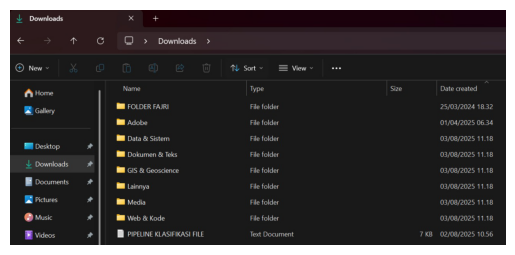

In [3]:
# Path ke file gambar
img_path = 'FINAL PRESENTATION.jpg'
# Membaca dan menampilkan gambar
img = mpimg.imread(img_path)
plt.imshow(img)
plt.axis('off')  # Hilangkan sumbu
plt.show()

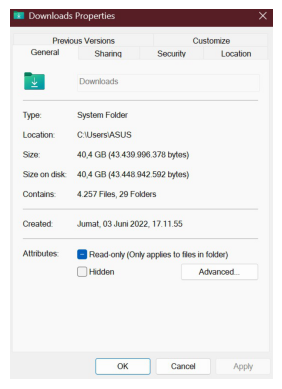

In [4]:
# Path ke file gambar
img_path2 = 'FINAL ATTRIBUTE.jpg'
# Membaca dan menampilkan gambar
img = mpimg.imread(img_path2)
plt.imshow(img)
plt.axis('off')  # Hilangkan sumbu
plt.show()